# ListIQ — Exploratory Data Analysis (Sprint 2)

**Goal:** Produce quotable EDA findings from the unified `all_platforms.csv` dataset (5,919 rows across eBay, Poshmark, and Depop).

**Analyses:**
1. **Platform-Item Fit** — Kruskal-Wallis hypothesis test on price by platform per category
2. **True Cost of Reselling** — Net profit and effective hourly rate after fees, shipping, and time
3. **"Don't Sell" Candidates** — Items earning below California minimum wage ($15/hr)
4. **Best Platform by Net Profit** — Which platform yields the highest median net profit per category
5. **Sell Velocity** — Poshmark-only days-to-sale analysis by category

**Important caveats:**
- Depop `final_sale_price` is the **listed** price, not a confirmed sold price
- eBay rows have **null** `days_to_sale`, `listing_day_of_week`, `listing_time`, and `original_list_price`
- Depop rows have **null** `condition` and `sold_date`

## Section 0: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

# Figures output directory
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)


def save_fig(name, fig=None):
    """Save current figure to figures/ as PNG and display inline."""
    target = fig or plt.gcf()
    target.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()

## Section 1: Data Load & Sanity Check

In [2]:
df = pd.read_csv("../data/cleaned/all_platforms.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n=== Platform distribution ===")
print(df["platform"].value_counts().to_string())
print(f"\n=== Category distribution ===")
print(df["item_category"].value_counts().to_string())
print(f"\n=== Null audit ===")
null_counts = df.isnull().sum()
null_pcts = (null_counts / len(df) * 100).round(1)
null_report = pd.DataFrame({"nulls": null_counts, "pct": null_pcts})
print(null_report[null_report["nulls"] > 0].sort_values("nulls", ascending=False).to_string())

Shape: 5919 rows x 16 columns

=== Platform distribution ===
platform
eBay        3910
Poshmark    1190
Depop        819

=== Category distribution ===
item_category
sneakers           893
denim jacket       882
midi dress         867
handbag            759
leather jacket     639
vintage t-shirt    633
crossbody bag      629
blazer             617

=== Null audit ===
                     nulls   pct
original_list_price   4923  83.2
price_discount_pct    4923  83.2
days_to_sale          4729  79.9
listing_day_of_week   3910  66.1
listing_time          3910  66.1
sold_date              819  13.8
brand                  199   3.4


### Category × Platform coverage

- **Three-way categories** (eBay + Poshmark + Depop): denim jacket, midi dress, sneakers, handbag
- **Two-way categories** (eBay + Poshmark only): blazer, vintage t-shirt, leather jacket, crossbody bag

In [3]:
# Verify category x platform coverage
coverage = df.groupby(["item_category", "platform"]).size().unstack(fill_value=0)
print(coverage.to_string())

platform         Depop  Poshmark  eBay
item_category                         
blazer               0       143   474
crossbody bag        0       142   487
denim jacket       250       141   491
handbag             69       190   500
leather jacket       0       143   496
midi dress         250       144   473
sneakers           250       144   499
vintage t-shirt      0       143   490


## Section 2: Platform-Item Fit Hypothesis Test

**Question:** Do sale prices differ significantly across platforms for each category?

**Method:** Kruskal-Wallis H-test (non-parametric, does not assume normality) on `final_sale_price` grouped by platform, run independently per category.

> **Caveat:** Depop's `final_sale_price` is the *listed* price, not a confirmed sold price. Interpret Depop price comparisons as "market positioning" rather than "what items actually sold for."

In [4]:
# 2a. Kruskal-Wallis test per category
categories = sorted(df["item_category"].unique())
kw_results = []

for cat in categories:
    cat_df = df[df["item_category"] == cat]
    groups = [g["final_sale_price"].dropna().values for _, g in cat_df.groupby("platform")]
    # Need at least 2 groups to compare
    if len(groups) >= 2:
        stat, pval = kruskal(*groups)
        n_platforms = len(groups)
    else:
        stat, pval, n_platforms = np.nan, np.nan, len(groups)
    kw_results.append({
        "category": cat,
        "n_platforms": n_platforms,
        "H_statistic": round(stat, 2),
        "p_value": round(pval, 6),
        "significant (p<0.05)": pval < 0.05 if not np.isnan(pval) else None,
    })

kw_df = pd.DataFrame(kw_results)
print("=== Kruskal-Wallis H-test: final_sale_price by platform, per category ===\n")
print(kw_df.to_string(index=False))

n_sig = kw_df["significant (p<0.05)"].sum()
print(f"\n→ {n_sig} of {len(kw_df)} categories show statistically significant price differences across platforms (p < 0.05)")

=== Kruskal-Wallis H-test: final_sale_price by platform, per category ===

       category  n_platforms  H_statistic  p_value  significant (p<0.05)
         blazer            2         0.71 0.400385                 False
  crossbody bag            2         9.68 0.001862                  True
   denim jacket            3        39.16 0.000000                  True
        handbag            3        20.16 0.000042                  True
 leather jacket            2        18.76 0.000015                  True
     midi dress            3        27.09 0.000001                  True
       sneakers            3        41.00 0.000000                  True
vintage t-shirt            2        40.87 0.000000                  True

→ 7 of 8 categories show statistically significant price differences across platforms (p < 0.05)


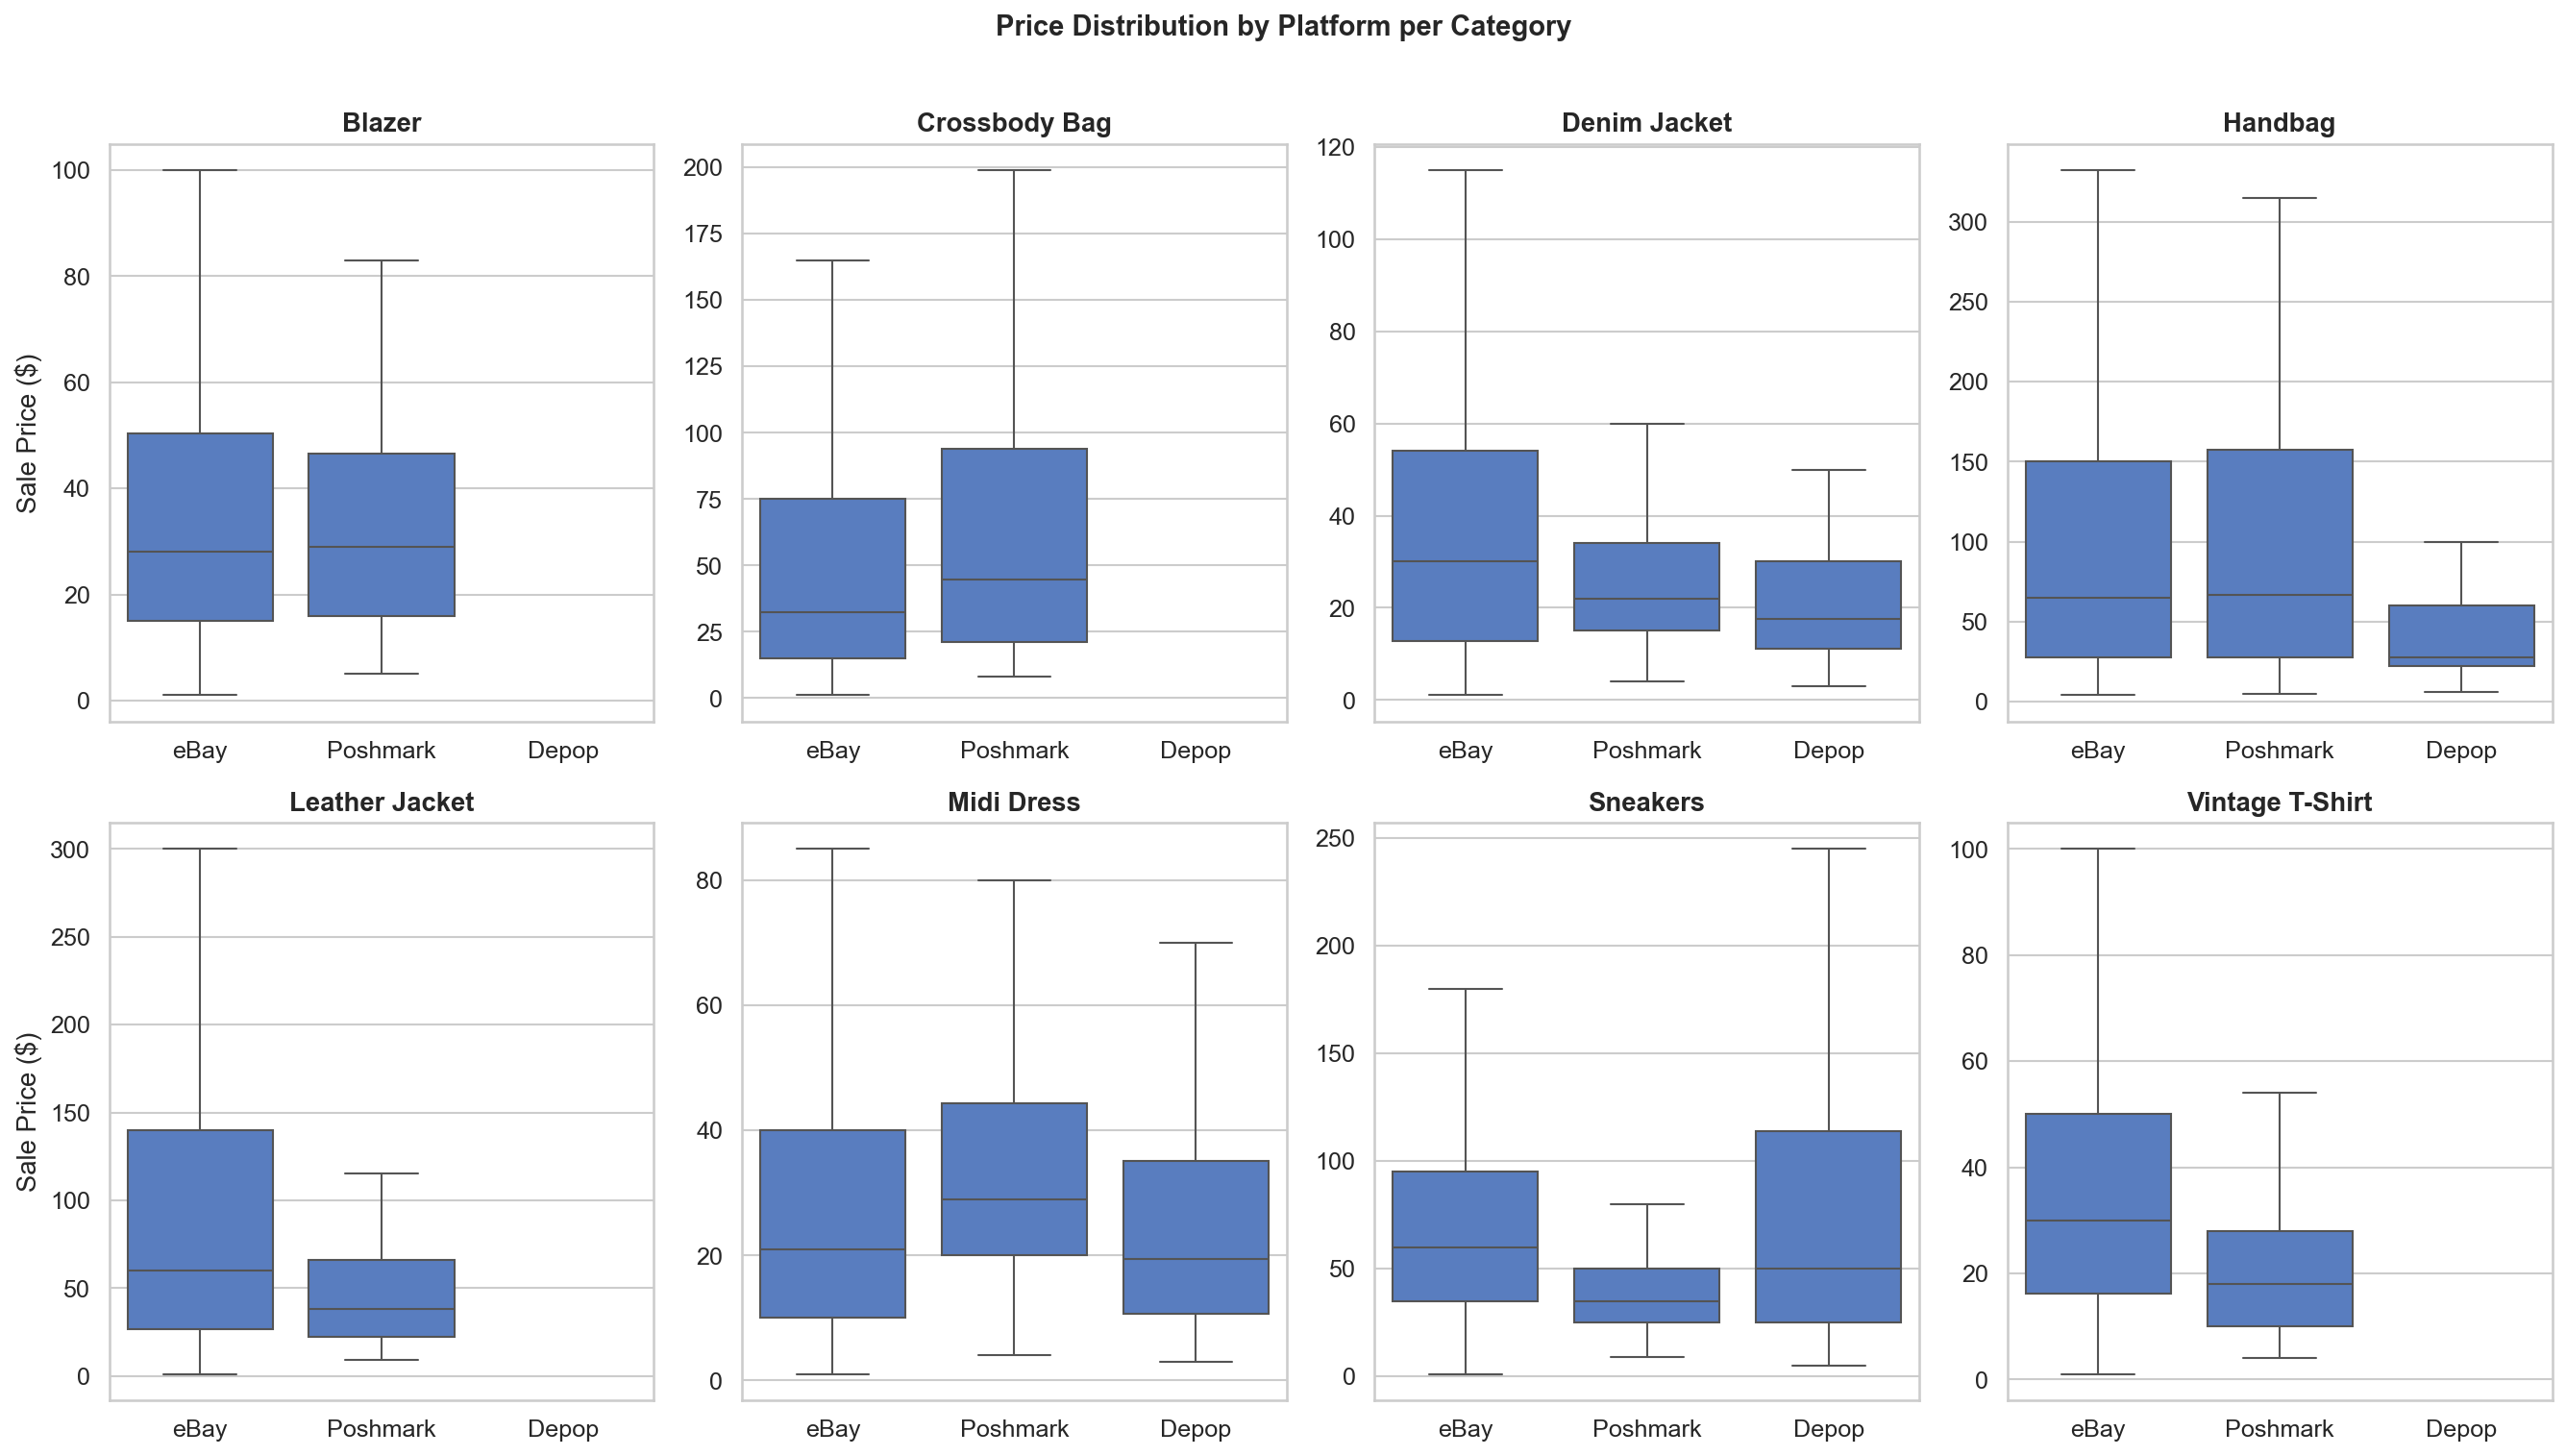

In [5]:
# 2b. Box plots: price by platform per category
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_df = df[df["item_category"] == cat]
    sns.boxplot(data=cat_df, x="platform", y="final_sale_price", ax=axes[i],
                showfliers=False, order=["eBay", "Poshmark", "Depop"])
    axes[i].set_title(cat.title(), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Sale Price ($)" if i % 4 == 0 else "")

fig.suptitle("Price Distribution by Platform per Category", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
save_fig("price_by_platform_boxplots")

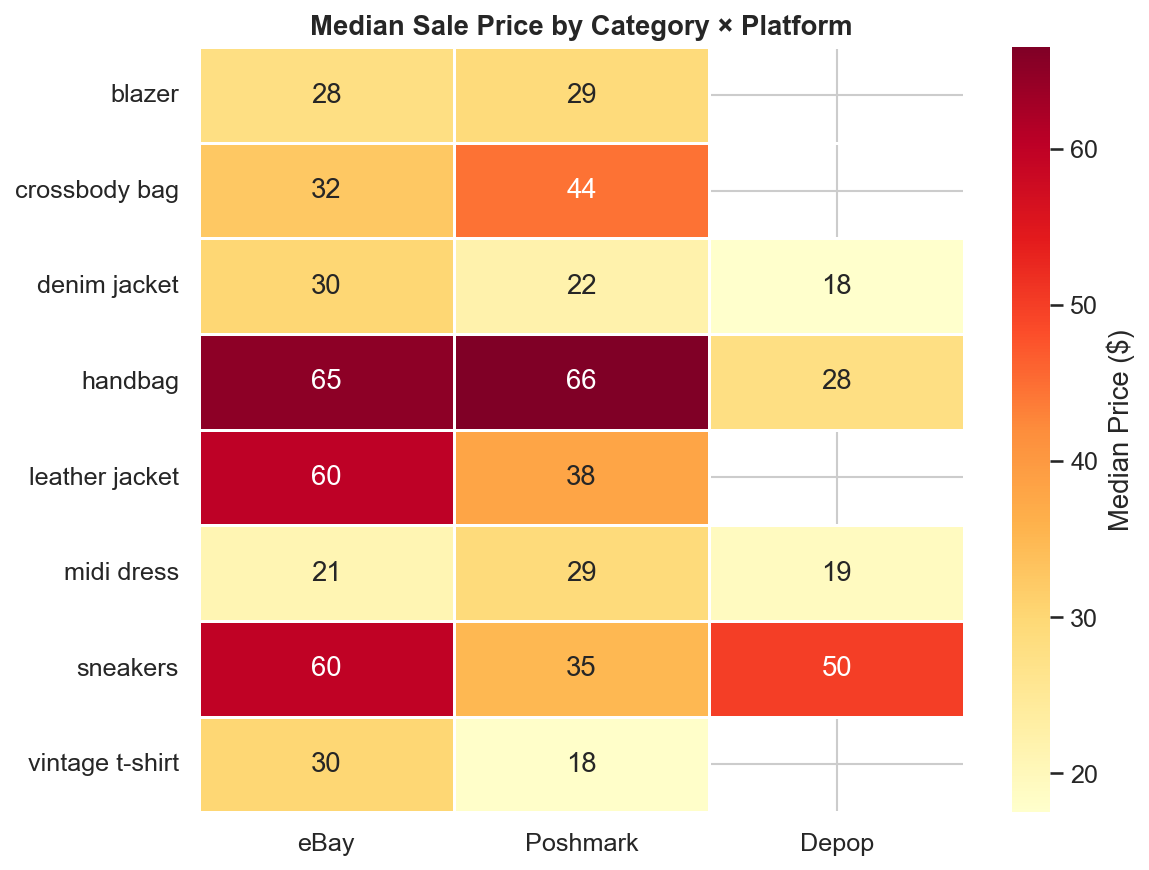

In [6]:
# 2c. Heatmap: median price by category x platform
median_prices = df.pivot_table(values="final_sale_price", index="item_category",
                                columns="platform", aggfunc="median")
# Reorder columns
median_prices = median_prices.reindex(columns=["eBay", "Poshmark", "Depop"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(median_prices, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Median Price ($)"})
ax.set_title("Median Sale Price by Category × Platform", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
save_fig("median_price_heatmap")

## Section 3: True Cost of Reselling

**Question:** What is the effective hourly rate for reselling after platform fees, shipping, and time?

### Assumptions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **Poshmark fee** | 20% | Flat 20% commission on sales ≥$15 |
| **eBay fee** | 13% | ~12.9% final value fee (category avg) |
| **Depop fee** | 10% | 10% flat commission |
| **Shipping** | $5.99 | Defensible average for clothing (USPS First Class / Priority envelope) |
| **Time per item** | 35 min | 10 min prep + 5 min photo + 5 min listing + 5 min packing + 10 min post office |

**Formula:**
- `net_profit = final_sale_price × (1 - platform_fee) - $5.99`
- `effective_hourly_rate = (net_profit / 35 min) × 60`

> **Note:** The 35-minute time estimate is applied uniformly. Real time-per-item varies by seller experience and item complexity. This is a conservative baseline for the "is it worth it?" question.

In [7]:
# Compute net profit and effective hourly rate
PLATFORM_FEES = {"Poshmark": 0.20, "eBay": 0.13, "Depop": 0.10}
SHIPPING_COST = 5.99
TIME_PER_ITEM_MIN = 35

df["platform_fee_rate"] = df["platform"].map(PLATFORM_FEES)
df["net_profit"] = df["final_sale_price"] * (1 - df["platform_fee_rate"]) - SHIPPING_COST
df["effective_hourly_rate"] = (df["net_profit"] / TIME_PER_ITEM_MIN) * 60

# Summary stats per platform
hourly_stats = df.groupby("platform")["effective_hourly_rate"].describe()[
    ["mean", "25%", "50%", "75%"]
].round(2)
hourly_stats.columns = ["mean", "25th_pctl", "median", "75th_pctl"]
print("=== Effective Hourly Rate by Platform ($/hr) ===")
print(f"    (Assumes {TIME_PER_ITEM_MIN} min/item, ${SHIPPING_COST} shipping)\n")
print(hourly_stats.to_string())

=== Effective Hourly Rate by Platform ($/hr) ===
    (Assumes 35 min/item, $5.99 shipping)

            mean  25th_pctl  median  75th_pctl
platform                                      
Depop      67.89      11.33   28.30      66.87
Poshmark  110.31      17.16   30.87      72.02
eBay      119.37      18.06   44.91     107.01


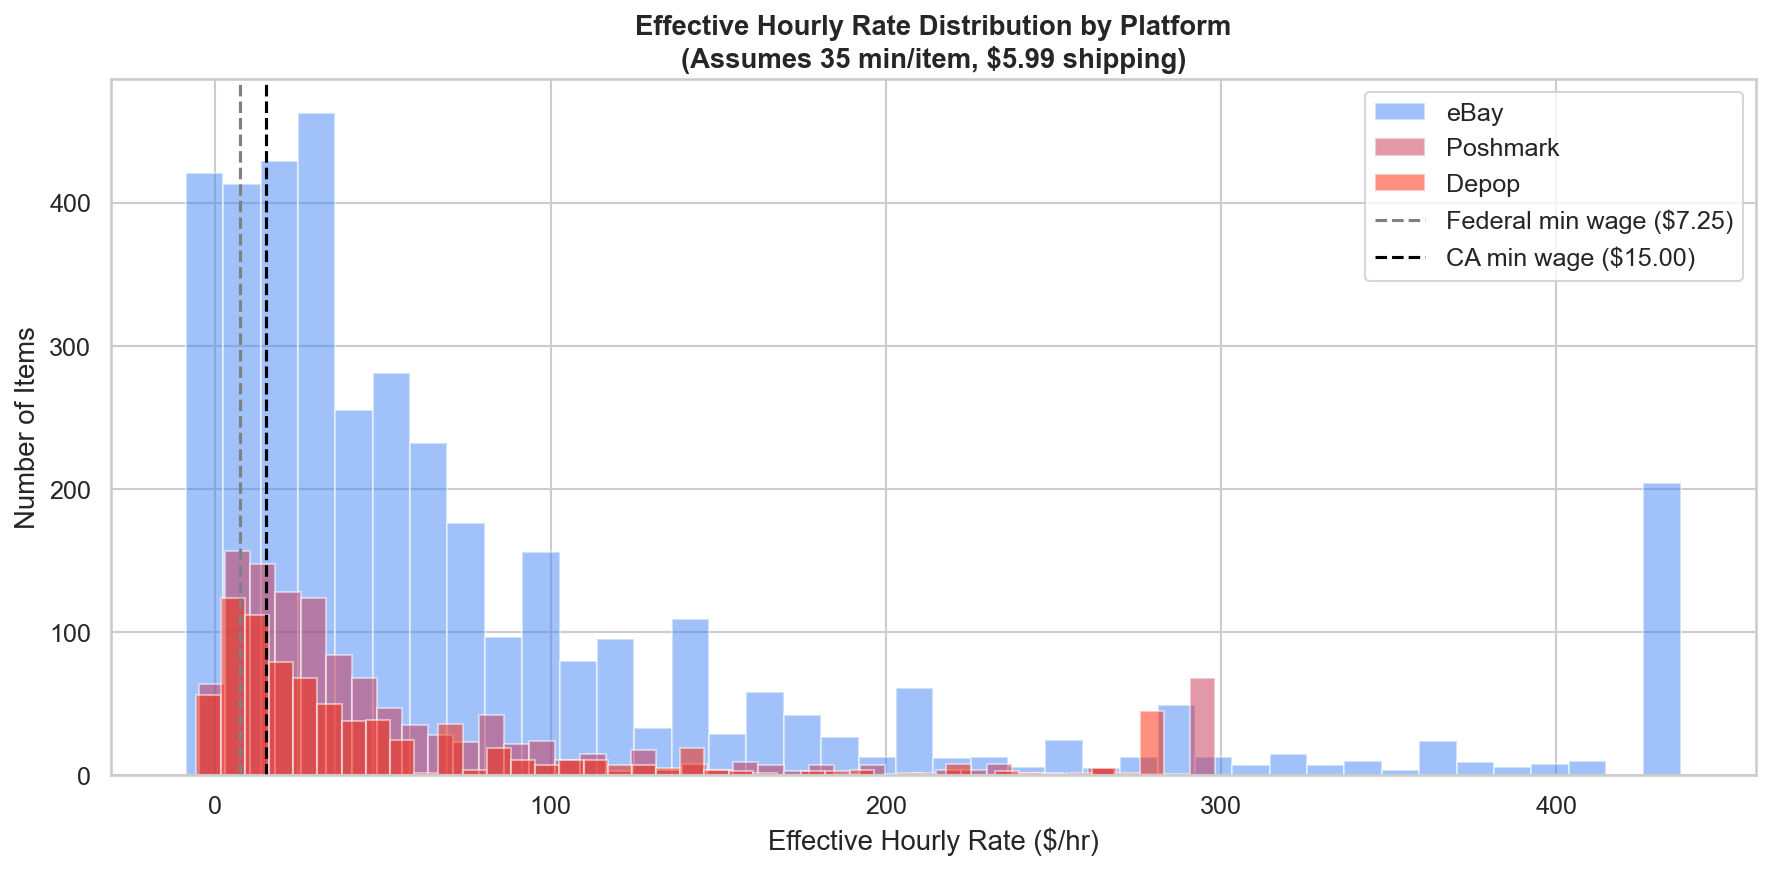

In [8]:
# Histogram of effective hourly rate per platform with min-wage benchmarks
fig, ax = plt.subplots(figsize=(12, 6))

platforms = ["eBay", "Poshmark", "Depop"]
colors = {"eBay": "#4285F4", "Poshmark": "#C83250", "Depop": "#FF2300"}

for plat in platforms:
    plat_data = df.loc[df["platform"] == plat, "effective_hourly_rate"]
    # Clip for display (some extreme values would stretch the axis)
    plat_data = plat_data.clip(upper=plat_data.quantile(0.95))
    ax.hist(plat_data, bins=40, alpha=0.5, label=plat, color=colors[plat], edgecolor="white")

ax.axvline(7.25, color="gray", linestyle="--", linewidth=1.5, label="Federal min wage ($7.25)")
ax.axvline(15.00, color="black", linestyle="--", linewidth=1.5, label="CA min wage ($15.00)")
ax.set_xlabel("Effective Hourly Rate ($/hr)")
ax.set_ylabel("Number of Items")
ax.set_title(f"Effective Hourly Rate Distribution by Platform\n(Assumes {TIME_PER_ITEM_MIN} min/item, ${SHIPPING_COST} shipping)",
             fontweight="bold")
ax.legend()
fig.tight_layout()
save_fig("hourly_rate_distribution")

## Section 4: "Don't Sell" Candidates

**Question:** What percentage of items earn below California minimum wage ($15/hr) after fees, shipping, and time?

This is the headline finding for the **"Worth It?"** feature pitch — identifying items that aren't worth a seller's time.

In [9]:
CA_MIN_WAGE = 15.00
df["dont_sell"] = df["effective_hourly_rate"] < CA_MIN_WAGE

# Overall
overall_pct = df["dont_sell"].mean() * 100
print(f"=== 'Don't Sell' Analysis (threshold: ${CA_MIN_WAGE}/hr) ===\n")
print(f"Overall: {overall_pct:.1f}% of items earn below CA minimum wage\n")

# By platform
print("--- By Platform ---")
by_platform = df.groupby("platform")["dont_sell"].mean().mul(100).round(1)
for plat, pct in by_platform.items():
    n = df[df["platform"] == plat]["dont_sell"].sum()
    total = len(df[df["platform"] == plat])
    print(f"  {plat}: {pct}% ({n}/{total} items)")

# By category
print("\n--- By Category ---")
by_category = df.groupby("item_category")["dont_sell"].mean().mul(100).round(1).sort_values(ascending=False)
for cat, pct in by_category.items():
    print(f"  {cat}: {pct}%")

=== 'Don't Sell' Analysis (threshold: $15.0/hr) ===

Overall: 24.1% of items earn below CA minimum wage

--- By Platform ---
  Depop: 34.8% (285/819 items)
  Poshmark: 23.5% (280/1190 items)
  eBay: 22.0% (861/3910 items)

--- By Category ---
  midi dress: 37.7%
  denim jacket: 36.2%
  vintage t-shirt: 32.1%
  blazer: 27.1%
  crossbody bag: 24.8%
  leather jacket: 13.6%
  handbag: 10.5%
  sneakers: 9.7%


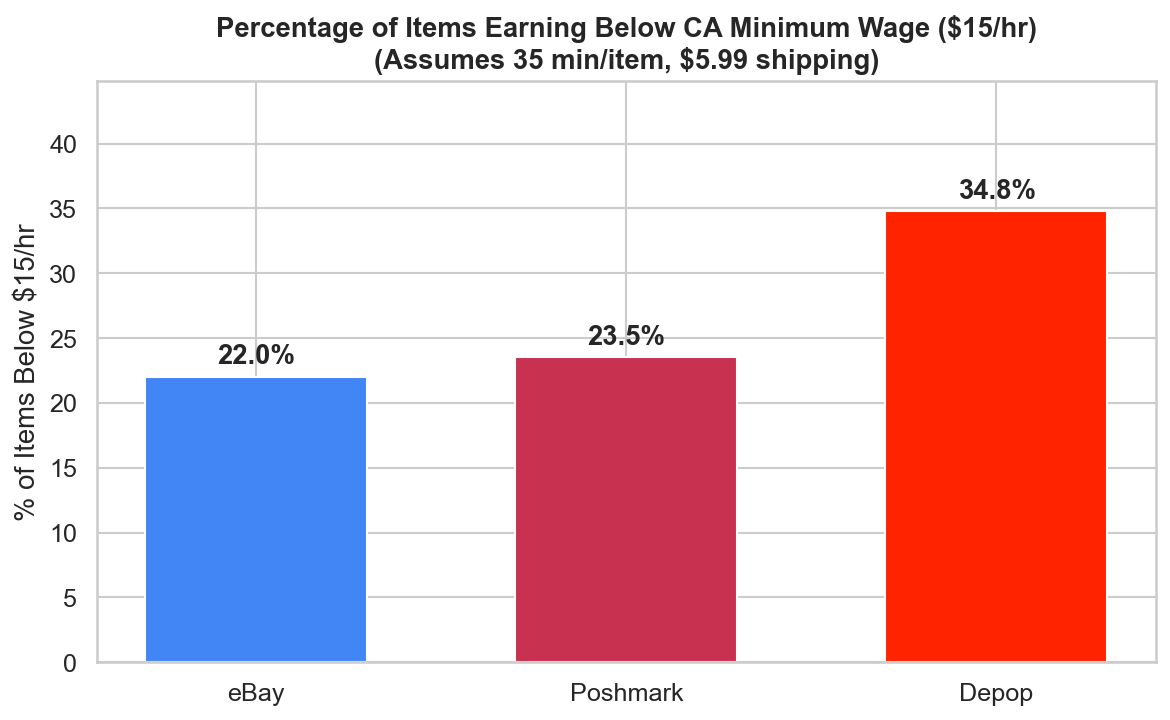

In [10]:
# Bar chart: % below $15/hr per platform
fig, ax = plt.subplots(figsize=(8, 5))

dont_sell_by_plat = df.groupby("platform")["dont_sell"].mean().mul(100).reindex(["eBay", "Poshmark", "Depop"])
bars = ax.bar(dont_sell_by_plat.index, dont_sell_by_plat.values,
              color=[colors[p] for p in dont_sell_by_plat.index], edgecolor="white", width=0.6)

for bar, val in zip(bars, dont_sell_by_plat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold")

ax.set_ylabel("% of Items Below $15/hr")
ax.set_title(f"Percentage of Items Earning Below CA Minimum Wage ($15/hr)\n(Assumes {TIME_PER_ITEM_MIN} min/item, ${SHIPPING_COST} shipping)",
             fontweight="bold")
ax.set_ylim(0, max(dont_sell_by_plat.values) + 10)
fig.tight_layout()
save_fig("dont_sell_by_platform")

## Section 5a: Best Platform Per Category by Net Profit

**Question:** Which platform yields the highest median net profit for each category?

All 8 categories included — 4 three-way (eBay + Poshmark + Depop) and 4 two-way (eBay + Poshmark). NaN cells indicate that platform has no data for that category.

> **Caveat:** Depop net profit is based on *listed* prices, not confirmed sales. Depop's lower fee (10%) makes it appear more profitable on paper, but these are not confirmed transactions.

=== Median Net Profit by Category × Platform ===

platform          eBay  Poshmark  Depop
item_category                          
blazer           18.37     17.21    NaN
crossbody bag    22.28     29.61    NaN
denim jacket     20.11     11.61   9.76
handbag          50.53     47.21  19.21
leather jacket   46.21     24.41    NaN
midi dress       12.28     17.21  11.47
sneakers         46.20     22.01  39.01
vintage t-shirt  20.10      8.41    NaN

=== Best Platform (highest median net profit) ===

  blazer: eBay ($18.37)
  crossbody bag: Poshmark ($29.61)
  denim jacket: eBay ($20.11)
  handbag: eBay ($50.53)
  leather jacket: eBay ($46.21)
  midi dress: Poshmark ($17.21)
  sneakers: eBay ($46.20)
  vintage t-shirt: eBay ($20.10)


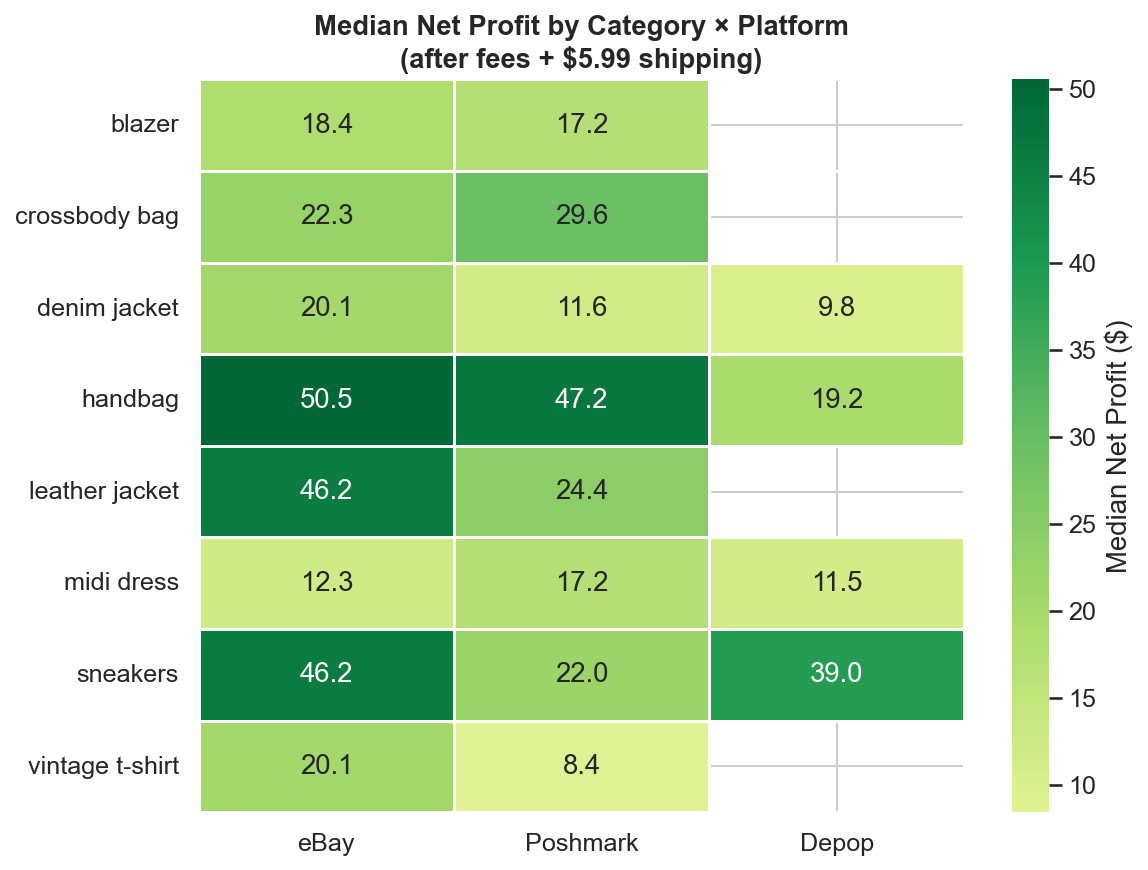

In [11]:
# Median net profit by category x platform
net_profit_pivot = df.pivot_table(values="net_profit", index="item_category",
                                   columns="platform", aggfunc="median")
net_profit_pivot = net_profit_pivot.reindex(columns=["eBay", "Poshmark", "Depop"])

# Identify best platform per category
best_platform = net_profit_pivot.idxmax(axis=1)

print("=== Median Net Profit by Category × Platform ===\n")
print(net_profit_pivot.round(2).to_string())
print(f"\n=== Best Platform (highest median net profit) ===\n")
for cat, plat in best_platform.items():
    val = net_profit_pivot.loc[cat, plat]
    print(f"  {cat}: {plat} (${val:.2f})")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(net_profit_pivot, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, center=0, cbar_kws={"label": "Median Net Profit ($)"})
ax.set_title("Median Net Profit by Category × Platform\n(after fees + $5.99 shipping)",
             fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
save_fig("best_platform_heatmap")

### Interpretation notes

- **Uneven sample sizes:** eBay (3,910 rows), Poshmark (1,190), Depop (819). Larger samples produce more stable medians — eBay's estimates are the most robust; Depop's handbag median is based on only 69 items.
- **"Wins" = per-item median net profit**, not a holistic platform comparison. A platform could "win" on median net profit but lose on sell-through rate, time-to-sale, or buyer reach.
- **Depop figures use listed prices, not sold prices.** Depop's lower platform fee (10% vs. 13–20%) inflates its apparent net profit. These are market positioning signals, not confirmed sale outcomes.

## Section 5b: Poshmark Sell Velocity by Category

**Question:** Which categories sell fastest on Poshmark?

Poshmark is the **only platform** with `days_to_sale` data. eBay and Depop have null values for this field — eBay because the search-results page doesn't expose listing dates, and Depop because it doesn't expose sold history publicly.

This is the velocity signal we have today; eBay and Depop require additional data sources for parity. Together with Section 5a (net profit ranking), this feeds the platform routing story for Sprint 3.

=== Poshmark Sell Velocity by Category ===

                 median_days  mean_days  n_items
item_category                                   
vintage t-shirt         20.0       64.4      143
handbag                 21.5       72.8      190
sneakers                22.5       71.3      144
midi dress              23.0       75.2      144
leather jacket          33.0       96.0      143
blazer                  35.0      104.7      143
crossbody bag           37.5       73.6      142
denim jacket            39.0       95.6      141

Fastest: vintage t-shirt (median 20 days)
Slowest: denim jacket (median 39 days)


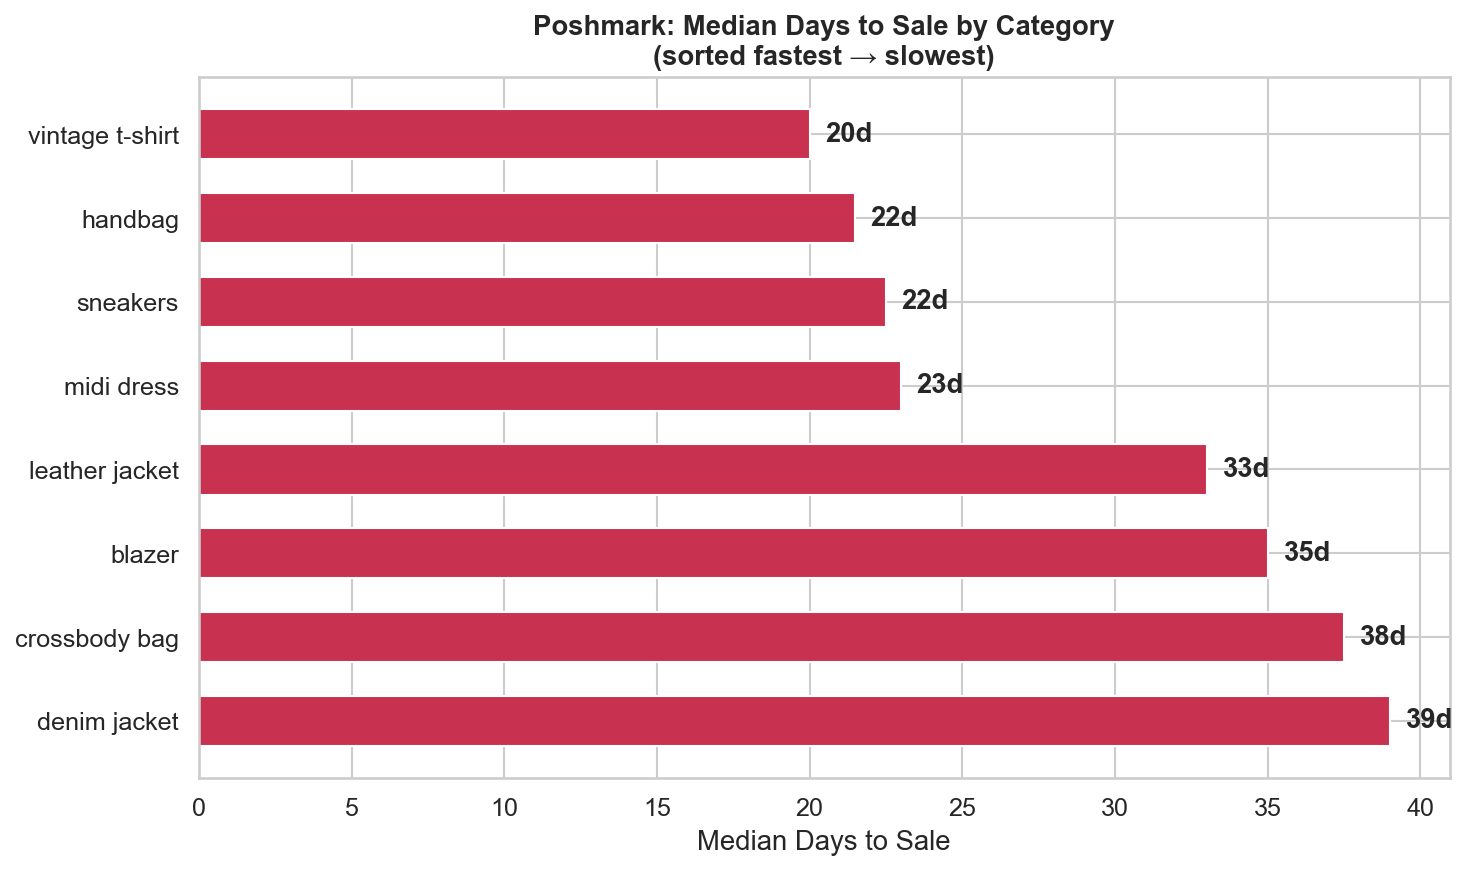

In [12]:
# Poshmark sell velocity by category
posh = df[df["platform"] == "Poshmark"].dropna(subset=["days_to_sale"])

velocity = posh.groupby("item_category")["days_to_sale"].agg(["median", "mean", "count"])
velocity.columns = ["median_days", "mean_days", "n_items"]
velocity = velocity.sort_values("median_days")

print("=== Poshmark Sell Velocity by Category ===\n")
print(velocity.round(1).to_string())
print(f"\nFastest: {velocity.index[0]} (median {velocity.iloc[0]['median_days']:.0f} days)")
print(f"Slowest: {velocity.index[-1]} (median {velocity.iloc[-1]['median_days']:.0f} days)")

# Bar chart sorted fastest → slowest
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(velocity.index, velocity["median_days"], color="#C83250", edgecolor="white", height=0.6)

for bar, val in zip(bars, velocity["median_days"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}d", va="center", fontweight="bold")

ax.set_xlabel("Median Days to Sale")
ax.set_title("Poshmark: Median Days to Sale by Category\n(sorted fastest → slowest)", fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
save_fig("poshmark_velocity_by_category")

## Section 6: Findings Summary

Quotable findings for the progress report. All values computed programmatically from the analysis above.

In [13]:
print("=" * 60)
print("  LISTIQ EDA FINDINGS — Sprint 2")
print("=" * 60)

# 1. Kruskal-Wallis
n_sig = int(kw_df["significant (p<0.05)"].sum())
n_total = len(kw_df)
print(f"""
1. [Platform-Item Fit]
   {n_sig} of {n_total} categories show statistically significant price
   differences across platforms (Kruskal-Wallis, p < 0.05).
""")

# 2. Hourly rate
for plat in ["eBay", "Poshmark", "Depop"]:
    med = df.loc[df["platform"] == plat, "effective_hourly_rate"].median()
    mean = df.loc[df["platform"] == plat, "effective_hourly_rate"].mean()
    proxy_label = " (listed price proxy)" if plat == "Depop" else ""
    print(f"2{'abc'[['eBay','Poshmark','Depop'].index(plat)]}. [{plat} Hourly Rate]{proxy_label}")
    print(f"   Median effective hourly rate: ${med:.2f}/hr (mean ${mean:.2f}/hr)")
    print(f"   (Assumes {TIME_PER_ITEM_MIN} min/item, ${SHIPPING_COST} shipping)")
    print()

# 3. Don't sell
overall_pct = df["dont_sell"].mean() * 100
print(f"""3. [Don't Sell]
   {overall_pct:.1f}% of items in our dataset earn below California
   minimum wage (${CA_MIN_WAGE}/hr) after platform fees, shipping, and time.
""")

# 4. Platform routing
print("4. [Best Platform by Net Profit]")
for cat, plat in best_platform.items():
    val = net_profit_pivot.loc[cat, plat]
    proxy_label = " (listed price proxy)" if plat == "Depop" else ""
    print(f"   {cat}: {plat} (${val:.2f} median net profit){proxy_label}")
print()

# For Depop column specifically, print all Depop net profit values with caveat
depop_cats = net_profit_pivot["Depop"].dropna()
if not depop_cats.empty:
    print("   Note: Depop net profit figures below are based on listed prices,")
    print("   not confirmed sales (listed price proxy):")
    for cat, val in depop_cats.items():
        print(f"     {cat}: Depop ${val:.2f} (listed price proxy)")
    print()

# 5. Velocity
fastest_cat = velocity.index[0]
fastest_days = velocity.iloc[0]["median_days"]
slowest_cat = velocity.index[-1]
slowest_days = velocity.iloc[-1]["median_days"]
print(f"""5. [Poshmark Sell Velocity]
   On Poshmark, {fastest_cat} sells fastest at median {fastest_days:.0f} days;
   {slowest_cat} is slowest at {slowest_days:.0f} days.
   (eBay and Depop velocity data not available — requires additional data sources)
""")

# 6. Depop caveat
print("""6. [Depop Caveat]
   All Depop findings reflect LISTED prices, not confirmed sales.
   Depop does not expose sold history publicly. Cross-platform price
   comparisons involving Depop should be interpreted as market positioning.
   All Depop hourly rates and net profit figures are labeled
   "(listed price proxy)" throughout this report.
""")

print("=" * 60)

  LISTIQ EDA FINDINGS — Sprint 2

1. [Platform-Item Fit]
   7 of 8 categories show statistically significant price
   differences across platforms (Kruskal-Wallis, p < 0.05).

2a. [eBay Hourly Rate]
   Median effective hourly rate: $44.91/hr (mean $119.37/hr)
   (Assumes 35 min/item, $5.99 shipping)

2b. [Poshmark Hourly Rate]
   Median effective hourly rate: $30.87/hr (mean $110.31/hr)
   (Assumes 35 min/item, $5.99 shipping)

2c. [Depop Hourly Rate] (listed price proxy)
   Median effective hourly rate: $28.30/hr (mean $67.89/hr)
   (Assumes 35 min/item, $5.99 shipping)

3. [Don't Sell]
   24.1% of items in our dataset earn below California
   minimum wage ($15.0/hr) after platform fees, shipping, and time.

4. [Best Platform by Net Profit]
   blazer: eBay ($18.37 median net profit)
   crossbody bag: Poshmark ($29.61 median net profit)
   denim jacket: eBay ($20.11 median net profit)
   handbag: eBay ($50.53 median net profit)
   leather jacket: eBay ($46.21 median net profit)
   midi